In [1]:
import os
from dotenv import load_dotenv
from langchain_groq import ChatGroq

load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

llm_model = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0
)
result = llm_model.invoke("hello")
result

AIMessage(content='Hello. How can I assist you today?', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 36, 'total_tokens': 46, 'completion_time': 0.010846509, 'completion_tokens_details': None, 'prompt_time': 0.003445671, 'prompt_tokens_details': None, 'queue_time': 0.162054795, 'total_time': 0.01429218}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_3272ea2d91', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ecbfb-023d-7910-899b-141ab5b44954-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 36, 'output_tokens': 10, 'total_tokens': 46})

In [2]:
from langgraph.graph import StateGraph, START, END
from typing_extensions import TypedDict
from IPython.display import display, Image


class State(TypedDict):
    topic: str
    story: str
    enhanced_story: str
    final_story: str


def generate_story(state:State):
    response = llm_model.invoke(f"Write a one sentence story premise on {state['topic']}")
    return {'story': response.content}


def check_conflict(state:State):
    if "?" in state['story'] or "!" in state['story']:
        return "Fail"
    else:
        return "Pass"
    
def improved_story(state:State):
    response = llm_model.invoke(f"Enhance the story premise with vivid details: {state['story']}")
    return {'enhanced_story': response.content}

def polish_story(state:State):
    response = llm_model.invoke(f"Add an unexpected twist to this story premise: {state['enhanced_story']}")
    return {'final_story': response.content}

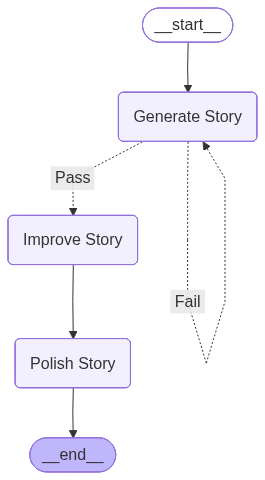

In [3]:
graph = StateGraph(State)

# nodes
graph.add_node("Generate Story", generate_story)
graph.add_node("Improve Story", improved_story)
graph.add_node("Polish Story", polish_story)

graph.add_edge(START, "Generate Story")
graph.add_conditional_edges("Generate Story", check_conflict, {"Fail": "Generate Story", "Pass": "Improve Story"})
graph.add_edge("Improve Story", "Polish Story")
graph.add_edge("Polish Story", END)

graph_builder = graph.compile()

display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [5]:
response = graph_builder.invoke({"topic": "rabbit and tortoise"})

In [12]:
response

{'topic': 'rabbit and tortoise',
 'story': 'In a modern retelling of the classic fable, a speedy rabbit named Rosie and a wise tortoise named Max form an unlikely friendship as they embark on a thrilling adventure to save their forest home from destruction.',
 'enhanced_story': "In a sun-dappled forest, where wildflowers swayed gently in the breeze and the scent of fresh earth filled the air, a speedy rabbit named Rosie lived a life of reckless abandon. Her fur was a mesmerizing mosaic of brown and white, with a distinctive crescent-shaped mark on her forehead that shone like a tiny moon. Rosie's eyes sparkled with mischief, and her long, powerful hind legs could propel her forward with incredible speed, leaving all other forest creatures in her dust.\n\nIn stark contrast, a wise and gentle tortoise named Max plodded along the forest floor, his shell a beautiful, swirling pattern of earthy tones that seemed to blend seamlessly with the surroundings. Max's eyes were pools of ancient wis

## Parallization

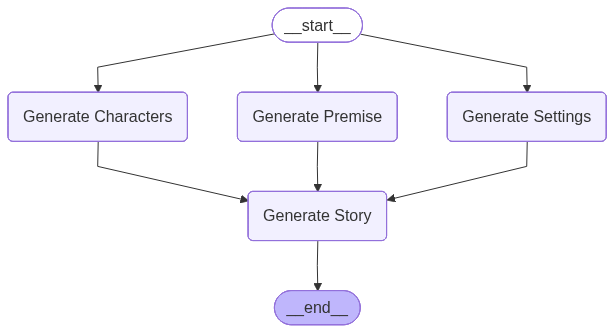

{'topic': 'time travel',
 'characters': 'Here are two character names and brief traits for a story about time travel:\n\n1. **Evelyn "Evie" Thompson**: A brilliant and resourceful 25-year-old physicist who has spent her entire career studying the mysteries of time travel. She\'s determined, fiercely independent, and has a dry sense of humor. Evie is the mastermind behind the time travel technology, but her impulsive nature often gets her into trouble.\n\n2. **August "Augie" Blackwood**: A charismatic and enigmatic 30-year-old historian who has a deep understanding of the past. He\'s a skilled researcher, a talented linguist, and has an uncanny ability to blend in with different time periods. Augie is initially hesitant to join Evie on her time-traveling adventures, but his curiosity and sense of adventure eventually win out, making him a valuable partner in navigating the complexities of the timeline.',
 'settings': "**The Time Traveler's Sanctum**\n\nIn the heart of a dense, mist-shro

In [13]:
import os 
from dotenv import load_dotenv 
from langgraph.graph import StateGraph, START, END 
from langchain_groq import ChatGroq 
from typing_extensions import TypedDict 
from IPython.display import display, Image

load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

model = ChatGroq( model="llama-3.3-70b-versatile", temperature=0.8 )

class State(TypedDict): 
    topic: str 
    characters: str 
    settings: str 
    premise: str 
    final_story: str


def generate_character(state:State): 
    """Generate the characters of the story""" 
    response = model.invoke(f"Create two character names and brief traits for a story about {state['topic']}") 
    return {"characters": response.content}

def generate_settings(state:State): 
    """Generate the settings of the story""" 
    response = model.invoke(f"Generate a vivid settings for a story about {state['topic']}") 
    return {"settings": response.content}

def generate_premise(state:State): 
    """Generate the premise of the story""" 
    response = model.invoke(f"Write a one sentence plot premise for a story about {state['topic']}") 
    return {"premise": response.content}

def generate_story(state:State): 
    """Generate the story""" 
    response = model.invoke(f"""Write a story introduction using these elements. 
                            Characters: {state["characters"]} 
                            Settings: {state["settings"]} 
                            Premise: {state["premise"]}""") 
    return {"final_story": response.content}

graph = StateGraph(State)

graph.add_node("Generate Characters", generate_character) 
graph.add_node("Generate Settings", generate_settings) 
graph.add_node("Generate Premise", generate_premise) 
graph.add_node("Generate Story", generate_story)

graph.add_edge(START, "Generate Characters") 
graph.add_edge(START, "Generate Settings") 
graph.add_edge(START, "Generate Premise") 
graph.add_edge("Generate Characters", "Generate Story") 
graph.add_edge("Generate Settings", "Generate Story") 
graph.add_edge("Generate Premise", "Generate Story") 
graph.add_edge("Generate Story", END)

graph_builder = graph.compile()

display(Image(graph_builder.get_graph().draw_mermaid_png()))


state = {"topic": "time travel"}
response = graph_builder.invoke(state)
response

In [14]:
llm_model.invoke("Give me latitute and longitute of New York")

AIMessage(content='The latitude and longitude of New York City are:\n\n* Latitude: 40.7128° N\n* Longitude: 74.0060° W\n\nNote: These coordinates are for the city center, specifically Times Square. The exact coordinates may vary depending on the specific location within New York City.', additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 62, 'prompt_tokens': 47, 'total_tokens': 109, 'completion_time': 0.180103744, 'completion_tokens_details': None, 'prompt_time': 0.007195868, 'prompt_tokens_details': None, 'queue_time': 0.053162431, 'total_time': 0.187299612}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019ed151-4f21-7f70-b59e-8d3d7b7484f3-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 47, 'output_tokens': 62, 'total_tokens': 109})

## Orchestration

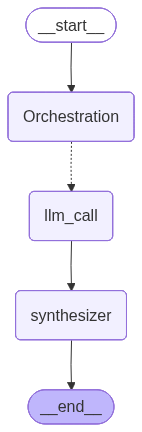

Report Section generated......
Complete section generated......
Complete section generated......
Complete section generated......
Complete section generated......
Complete section generated......


### Introduction to Agentic AI RAGs
Agentic AI RAGs (Retrieval-Augmented Generators) represent a significant development in artificial intelligence research, focusing on the integration of retrieval mechanisms with generative models to create more informed and contextually aware AI agents. The concept of Agentic AI RAGs is built around the idea of enhancing the capabilities of traditional AI models by enabling them to retrieve and incorporate relevant information from external knowledge sources, thereby improving their performance in various tasks such as question answering, text generation, and decision-making.

The significance of Agentic AI RAGs in AI research lies in their potential to address some of the current limitations of AI systems, including their lack of common sense, inability to understand nuanced contexts, and tendency to generate responses that are not grounded in real-world knowledge. By leveraging retrieval mechanisms, Agentic AI RAGs can access and utilize vast amounts of external knowledge, making them more reliable and effective in real-world applications.

Moreover, Agentic AI RAGs have the potential to facilitate more sophisticated and human-like interactions between AI systems and users, enabling AI agents to engage in more informed and contextually relevant conversations, provide more accurate and helpful responses to user queries, and make more informed decisions based on a deeper understanding of the situation at hand. As AI research continues to evolve, the development of Agentic AI RAGs is likely to play a pivotal role in shaping the future of artificial intelligence and its applications in various domains.

-----------------------------

### Technical Details of Agentic AI RAGs
#### Architecture
Agentic AI RAGs (Retrieval-Augmented Generation) are built using a combination of natural language processing (NLP) and information retrieval (IR) techniques. The architecture consists of three main components:
* **Retriever**: This module is responsible for retrieving relevant information from a large corpus of text based on a given input prompt. The retriever uses a dense vector database to store and query the corpus, allowing for efficient retrieval of relevant information.
* **Generator**: This module takes the retrieved information and generates a response based on the input prompt. The generator uses a transformer-based architecture to produce coherent and contextually relevant text.
* **Ranker**: This module ranks the generated responses based on their relevance and accuracy, ensuring that the final output is of high quality.

#### Functionality
The technical functionality of Agentic AI RAGs can be broken down into the following steps:
* **Text Encoding**: The input prompt is encoded into a dense vector using a pre-trained language model.
* **Information Retrieval**: The encoded prompt is used to query the vector database, retrieving a set of relevant documents or text snippets.
* **Generation**: The retrieved information is used to generate a response, which is then ranked by the ranker module.
* **Post-processing**: The final response is post-processed to ensure that it meets the required standards of quality and coherence.
* **Feedback Loop**: The output is fed back into the system, allowing for continuous learning and improvement of the model.

#### Key Technologies
Agentic AI RAGs rely on several key technologies, including:
* **Transformer Architecture**: The generator module uses a transformer-based architecture to produce coherent and contextually relevant text.
* **Dense Vector Databases**: The retriever module uses a dense vector database to store and query the corpus, allowing for efficient retrieval of relevant information.
* **Pre-trained Language Models**: The system uses pre-trained language models to encode the input prompt and generate responses.

-----------------------------

### Applications of Agentic AI RAGs
Agentic AI RAGs have a wide range of potential applications across various fields, including:
* **Robotics**: Agentic AI RAGs can be used to develop more advanced robotic systems that can learn, adapt, and interact with their environment in a more human-like way. This can lead to improvements in areas such as robotic navigation, manipulation, and human-robot interaction.
* **Healthcare**: Agentic AI RAGs can be applied in healthcare to develop personalized treatment plans, improve patient outcomes, and enhance the overall quality of care. For example, agentic AI RAGs can be used to analyze medical images, diagnose diseases, and develop targeted treatment strategies.
* **Finance**: Agentic AI RAGs can be used in finance to develop more advanced trading systems, improve risk management, and enhance portfolio optimization. This can lead to improved financial performance, reduced risk, and increased efficiency.
* **Education**: Agentic AI RAGs can be applied in education to develop more effective learning systems, improve student outcomes, and enhance the overall quality of education. For example, agentic AI RAGs can be used to develop personalized learning plans, adapt to individual learning styles, and provide real-time feedback.
* **Transportation**: Agentic AI RAGs can be used in transportation to develop more advanced autonomous vehicles, improve traffic management, and enhance the overall safety and efficiency of transportation systems. This can lead to reduced accidents, improved traffic flow, and increased mobility.

-----------------------------

### Challenges and Limitations of Agentic AI RAGs
#### Ethical Considerations
* **Lack of Transparency**: Agentic AI RAGs can be complex and difficult to understand, making it challenging to identify potential biases and ensure transparency in their decision-making processes.
* **Accountability**: As Agentic AI RAGs become more autonomous, it can be challenging to determine who is accountable for their actions and decisions.
* **Value Alignment**: Agentic AI RAGs may not always align with human values, which can lead to unintended consequences and raise ethical concerns.

#### Technical Hurdles
* **Scalability**: Agentic AI RAGs can be difficult to scale, as they require significant computational resources and complex software architectures.
* **Robustness**: Agentic AI RAGs can be sensitive to changes in their environment and may not be robust to errors or unexpected events.
* **Explainability**: Agentic AI RAGs can be challenging to interpret and understand, making it difficult to explain their decisions and actions.

#### Social and Environmental Implications
* **Job Displacement**: Agentic AI RAGs may displace human jobs, particularly in industries where tasks are repetitive or can be easily automated.
* **Environmental Impact**: Agentic AI RAGs may have a significant environmental impact, particularly if they are used to optimize processes that are not sustainable or environmentally friendly.
* **Dependence on Technology**: Agentic AI RAGs may create a dependence on technology, which can lead to negative consequences if the technology fails or is not available.

-----------------------------

### Future Directions for Agentic AI RAGs
As Agentic AI RAGs continue to evolve, several potential advancements and innovations are on the horizon. One possible direction is the integration of **multimodal interaction capabilities**, enabling RAGs to engage with users through various interfaces, such as voice, text, and visual inputs. This could lead to more natural and intuitive human-AI interactions, making RAGs more accessible and user-friendly.

Another future direction is the **development of explainable AI (XAI) techniques** for Agentic AI RAGs. As RAGs become more autonomous and complex, it is essential to understand their decision-making processes and provide transparent explanations for their actions. XAI techniques can help build trust and confidence in RAGs, enabling more effective human-AI collaboration.

The **incorporation of emotional intelligence and social skills** is also a potential future direction for Agentic AI RAGs. By enabling RAGs to understand and respond to human emotions, empathy, and social cues, they can become more effective and supportive companions, enhancing human-AI relationships.

Additionally, **edge AI and decentralized architectures** may play a significant role in the future development of Agentic AI RAGs. By processing data and making decisions at the edge, RAGs can reduce latency, improve real-time responsiveness, and enhance overall system efficiency.

Lastly, **hybrid approaches combining symbolic and connectionist AI** may emerge as a future direction for Agentic AI RAGs. By integrating the strengths of both symbolic and connectionist AI, RAGs can leverage the benefits of explicit knowledge representation and reasoning, while also exploiting the power of machine learning and neural networks. This hybrid approach can lead to more robust, flexible, and generalizable Agentic AI RAGs.

In [2]:
import os
import operator
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from typing import Annotated
from typing_extensions import TypedDict
from typing import Literal
from pydantic import BaseModel, Field
from IPython.display import display, Image, Markdown
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.types import Send

load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

model = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0.8
)

class Section(BaseModel):
  name: str = Field(description="name of this section in the report")
  description: str = Field(description="Breif overview of the main topics and concepts of the section")

class Sections(BaseModel):
  sections: list[Section] = Field(description="list of sections in the report")

planner = model.with_structured_output(Sections)

class State(TypedDict):
    topic: str
    sections: list[Section]
    completed_sections: Annotated[list, operator.add]
    final_report: str

class Worker(TypedDict):
  section: Section

def orchestration(state:State):
  """Orchestration that generates a plan for the report"""
  report_sections = planner.invoke(
      [
          SystemMessage(content="Generate a plan for the report"),
          HumanMessage(content=f"Generate a plan for a report on the topic {state['topic']}")
      ]
  )

  print("Report Section generated......")
  return {"sections": report_sections.sections}

def llm_call(state:Worker):
  """Worker writes the section of the report"""

  sections = model.invoke(
      [
          SystemMessage(
              content = "Write a report section following the provided name and description. Include no premeble for each section. Use Markdown formatting"
          ),
          HumanMessage(
              content=f"Here is the section name: {state['section'].name} and description: {state['section'].description}"
          )
      ]
  )

  print("Complete section generated......")
  return {"completed_sections": [sections.content]}

def assign_worker(state:State):
  """Assign a worker to each sections in the plan"""
  return [Send("llm_call", {"section": s}) for s in state["sections"]]

def synthesizer(state:State):
  """Synthesize the full report from sections"""
  completed = state["completed_sections"]
  return {"final_report": "\n\n-----------------------------\n\n".join(completed)}

# Graph
graph = StateGraph(State)

graph.add_node("Orchestration", orchestration)
graph.add_node("llm_call", llm_call)
graph.add_node("synthesizer", synthesizer)

graph.add_edge(START, "Orchestration")
graph.add_conditional_edges(
    "Orchestration",
    assign_worker,
    ["llm_call"]
)
graph.add_edge("llm_call", "synthesizer")
graph.add_edge("synthesizer", END)

compiled_graph = graph.compile()

display(Image(compiled_graph.get_graph().draw_mermaid_png()))

# Invokation
response = compiled_graph.invoke({"topic": "Create a report on Agentic AI RAGs"})

Markdown(response["final_report"])

# Evaluator Optimizer

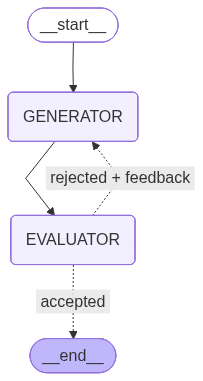

In [40]:
import os
import operator
from dotenv import load_dotenv
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph, START, END
from typing import Annotated
from typing_extensions import TypedDict
from typing import Literal
from pydantic import BaseModel, Field
from IPython.display import display, Image, Markdown
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.types import Send

load_dotenv()

os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

model = ChatGroq(
    model="llama-3.3-70b-versatile",
    temperature=0.8
)

class State(TypedDict):
    joke: str
    topic: str
    feedback: str
    funny_or_not: str

class Feedback(BaseModel):
    grade: Literal["Funny", "Not Funny"] = Field(description="Decide if the joke is funny or not")
    feedback: str = Field("Provide the feedback to improve the joke if the joke is not funny")

structured_model = model.with_structured_output(Feedback)


def generator(state:State):
    """LLM will generate a joke"""
    if state.get("feedback"):
        joke = model.invoke(
            f"Write a joke on {state['topic']} but taking into account the feedback {state['feedback']}"
        )
    else:
        joke = model.invoke(
            f"Write a joke on the topic {state['topic']}"
        )
    
    return {"joke": joke.content}


def evaluator(state:State):
    """LLM evaluates the joke"""
    evaluate = structured_model.invoke(f"Grade the joke {state['joke']}")
    return {"feedback": evaluate.feedback, "funny_or_not": evaluate.grade}

def route_joke(state:State):
    """Route back to joke generator or end based on the feedback from the evaluator"""
    if state["funny_or_not"] == "Funny":
        return "accepted"
    elif state["funny_or_not"] == "Not Funny":
        return "rejected + feedback"
    


    # Graph
graph = StateGraph(State)

graph.add_node("GENERATOR", generator)
graph.add_node("EVALUATOR", evaluator)

graph.add_edge(START, "GENERATOR")
graph.add_edge("GENERATOR", "EVALUATOR")
graph.add_conditional_edges(
    "EVALUATOR",
    route_joke,
    {
        "accepted": END,
        "rejected + feedback": "GENERATOR"
    }
)

evaluator_optimizer = graph.compile()

display(Image(evaluator_optimizer.get_graph().draw_mermaid_png()))

In [44]:
response = evaluator_optimizer.invoke({"topic": "Transfomers in LLM"})
response

{'joke': 'Why did the Transformer model go to therapy in the Large Language Model (LLM) world?\n\nBecause it was struggling to "transform" its thoughts and was feeling a little "dis-connected" from the rest of the neural network. But in the end, it just needed to "re-encode" its problems and "decode" a new perspective.',
 'topic': 'Transfomers in LLM',
 'feedback': "The joke is funny because it uses wordplay related to Transformer models, such as 'transform', 'dis-connected', 're-encode', and 'decode', which are terms commonly used in the context of LLMs. The humor comes from the clever use of these technical terms in a non-technical, therapeutic setting. However, the joke may not be funny to those who are not familiar with the technical terms used in the joke.",
 'funny_or_not': 'Funny'}